In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('cleaned_welface.csv')
df = df.dropna(subset=['label', 'content'])
df['label'] = df['label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Vectorize text
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), stop_words='english')
X_train = tfidf.fit_transform(train_df['content'])
X_test = tfidf.transform(test_df['content'])
y_train = train_df['label']
y_test = test_df['label']

# Train classifier
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("TF-IDF + Logistic Regression Results:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

TF-IDF + Logistic Regression Results:
Accuracy:  0.9542
F1 Score:  0.9489
Precision: 0.9501
Recall:    0.9477


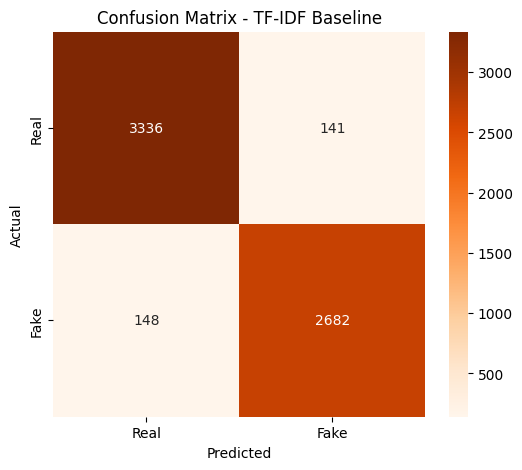

In [3]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF Baseline')
plt.show()

In [4]:
results = {
    'Model': [
        'TF-IDF + Logistic Regression',
        'BERT (fine-tuned, 3 epochs)'
    ],
    'Accuracy': [round(accuracy, 4), 0.9905],
    'F1 Score': [round(f1, 4), 0.9894],
    'Precision': [round(precision, 4), 0.9932],
    'Recall': [round(recall, 4), 0.9855]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Save for README
results_df.to_csv('model_comparison.csv', index=False)
print("\nSaved to model_comparison.csv")

                       Model  Accuracy  F1 Score  Precision  Recall
TF-IDF + Logistic Regression    0.9542    0.9489     0.9501  0.9477
 BERT (fine-tuned, 3 epochs)    0.9905    0.9894     0.9932  0.9855

Saved to model_comparison.csv


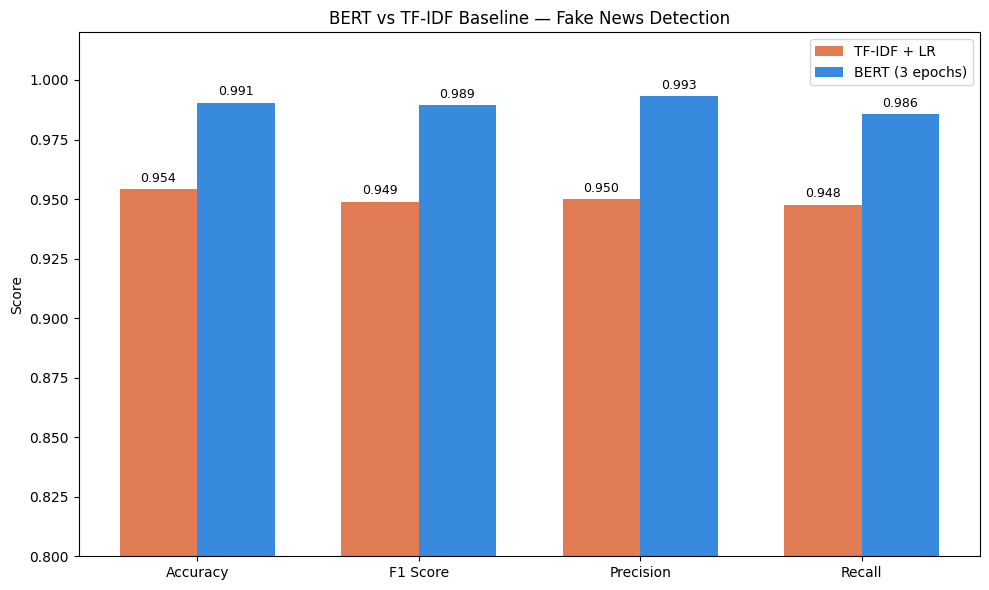

Chart saved as model_comparison.png


In [5]:
import numpy as np

metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
tfidf_scores = [results['Accuracy'][0], results['F1 Score'][0],
                results['Precision'][0], results['Recall'][0]]
bert_scores = [0.9905, 0.9894, 0.9932, 0.9855]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF + LR', color='#E07B54')
bars2 = ax.bar(x + width/2, bert_scores, width, label='BERT (3 epochs)', color='#378ADD')

ax.set_ylabel('Score')
ax.set_title('BERT vs TF-IDF Baseline — Fake News Detection')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(bars2, padding=3, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved as model_comparison.png")